In [12]:
#Flat Cylinder Approximation


# cartesian method top cylinder event generation

# #import libraries
# import numpy as np
# import matplotlib.pyplot as plt

# #define cylinder
# r = 1
# h = 2

# #define muons
# n = 100_000
# a = 2

# #coordinates (events) of muon on top surface on detector
# x_rect = np.random.uniform(-r,r,n)
# y_rect = np.random.uniform(-r,r,n)

# #test if points are within defined circle
# inside_circle = (x_rect**2 + y_rect**2) <= r**2

# #discard points outside circle
# x = x_rect[inside_circle]
# y = y_rect[inside_circle]

# # #number of generated versus kept points
# # print(f"Generated {n} points.")
# # print(f"Kept {len(x)} points inside the circle.")

# # #plot showing kept points
# # plt.figure(figsize = (5,5))
# # plt.scatter(x, y, s = 0.1, alpha = 1)
# # plt.title("Kept Points in Circle")
# # plt.xlim(-1, 1)
# # plt.ylim(-1, 1)
# # plt.show()



#polar method (r, phi) top cylinder point generation

import numpy as np
import matplotlib.pyplot as plt


#define cylinder
r = 1
h = 2

#define muons
n = 100_000
a = 2

#coordinates (events) of muon on top surface on detector
#phi = np.random.rand(n) * np.pi * 2
phi = np.random.uniform(0, 2 * np.pi * n)
R = r * np.sqrt(np.random.rand(n)) #random.rand = random.uniform (0, 1, n)

x = R * np.cos(phi)
y = R * np.sin(phi)

The Equation to solve is:
       a_sym + 1           
1 - cos         (θ_sym) = u

Solving for theta gives:
    ⎛           1    ⎞
    ⎜       ─────────⎟
    ⎜       a_sym + 1⎟
acos⎝(1 - u)         ⎠
Generated 10000000 muons.
Total muons that intersected the detector: 5774597


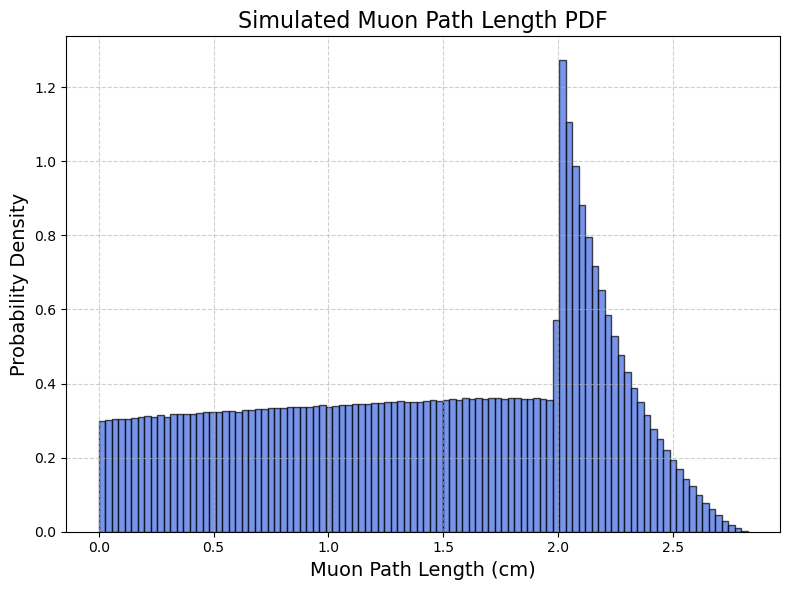

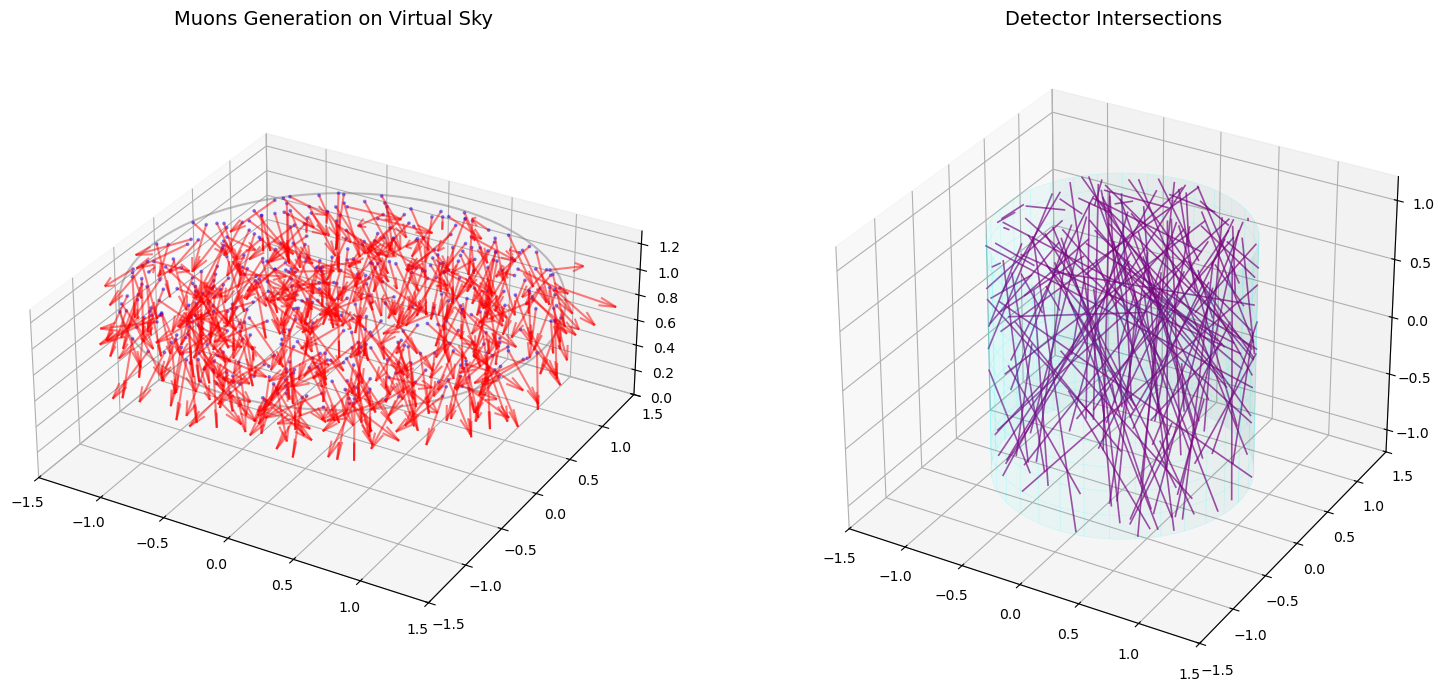

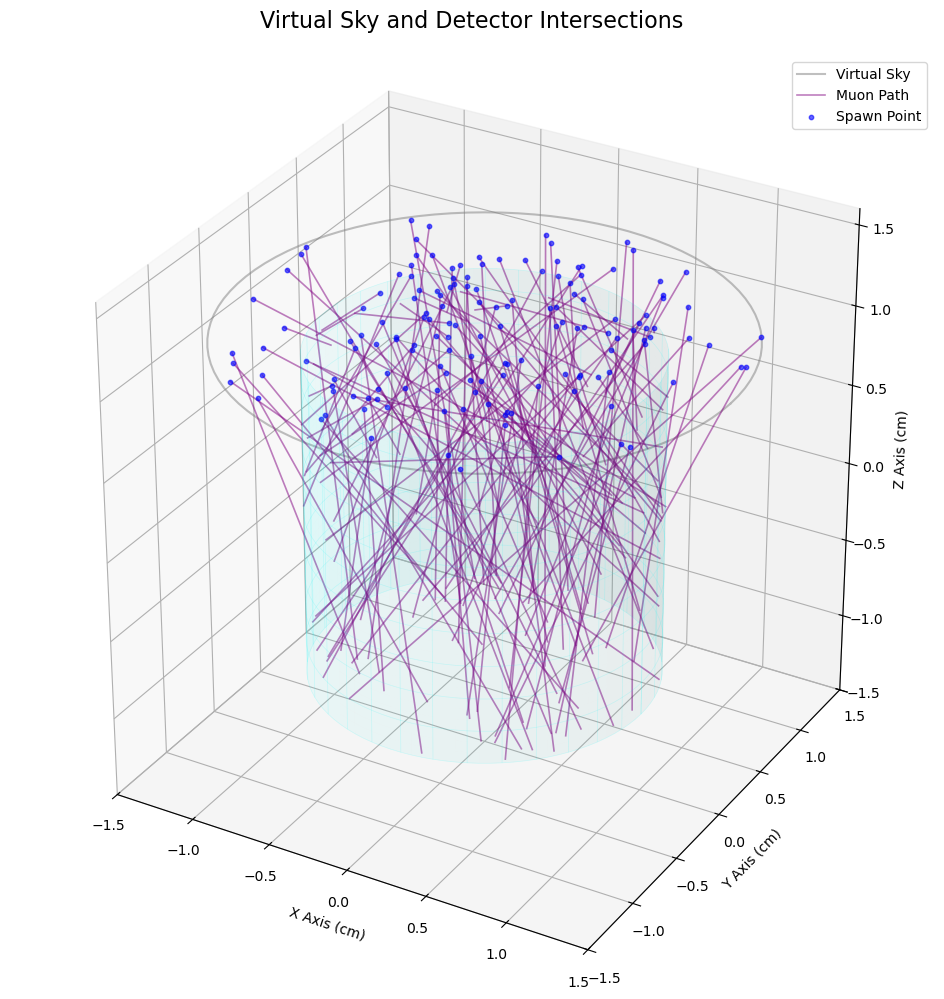

In [6]:
#Virtual sky method (geometry does the work, but less efficient)

import numpy as np

#Cylinder setup
r = 1
h = 2
z_sky = 1.1 #sky height
r_sky = 3 #sky radius
n = 10_000_000

#Generate muons on sky
phi_sky = np.random.uniform(0, 2 * np.pi, n)
R_sky = r_sky * np.sqrt(np.random.rand(n))

#Translate to cartesian
x0 = R_sky * np.cos(phi_sky)
y0 = R_sky * np.sin(phi_sky)
z0 = np.full(n, z_sky) #gives the value 1.1 to each generated x0 and y0 point

#Angle generation that follows cos^a without needing to filter
a = 2 #cos^a variable
phi = np.random.uniform(0, 2*np.pi, n) #Compass direction range
theta = np.arccos(np.random.rand(n) ** (1 / (a + 1)))


#Calculus to make theta generate according to the cos^a function instead of making it random and then filtering
import sympy as sp #Allows symbolic math
theta_sym, a_sym, u  = sp.symbols('theta_sym a_sym u', positive=True) #Ties written variables for python to algebraic symbols in sympy
pdf = (a_sym + 1) * (sp.cos(theta_sym)**a_sym) * (sp.sin(theta_sym)) #Gives our pdf of muon angle with normalization constant * desired distribution * geometric area equation factor
cdf = sp.integrate(pdf, theta_sym) #Integrates our pdf to find probability of being within any 0 to theta range
cdf_normalized = 1 - sp.cos(theta_sym)**(a_sym + 1) #Makes cdf spit out 0 at 0, and 1 as angle increases to pi/2
equation = sp.Eq(cdf_normalized, u) #Sets cdf equal to a random number variable so that we can solve for an output theta with an input of random cdf percentage

print("The Equation to solve is:")
sp.pprint(equation) #Shows equation to solve

solutions = sp.solve(equation, theta_sym) #Solvesequation for theta

print("\nSolving for theta gives:")
sp.pprint(solutions[0]) #Shows solved equation


          




#Build direction vectors by turning muon positions and angles into a continuous line
vx = np.sin(theta) * np.cos(phi) #distance from vertical axis * distance in x direction to give cartesian
vy = np.sin(theta) * np.sin(phi) #d from z-axis * distance in y to give cartesian coordinates
vz = -np.cos(theta) #distance along z axis (negative because downward)












#BELOW IS AI WORK TO COMPLETE CONCEPTS FOR POSTER PRESENTATION. DELETE AND RECREATE LATER.


# --- BLOCK 1: DETECTOR INTERSECTION & PATH LENGTHS ---
# Using the "Slab Method" for ray-cylinder intersection

# 1. Define Z-planes (Top and Bottom of the cylinder centered at z=0)
z_top = h / 2.0
z_bottom = -h / 2.0

# Calculate time (t) to hit the infinite horizontal planes
# Note: vz is negative, so t_top will be smaller (hit first) than t_bottom
t_top = (z_top - z0) / vz
t_bottom = (z_bottom - z0) / vz

# 2. Define Infinite Cylinder Walls (Quadratic equation)
a_quad = vx**2 + vy**2
b_quad = 2 * (x0*vx + y0*vy)
c_quad = x0**2 + y0**2 - r**2

disc = b_quad**2 - 4*a_quad*c_quad

# Safely calculate wall intersections (ignore negative discriminants to avoid math errors)
t_wall_in = np.where(disc >= 0, (-b_quad - np.sqrt(np.maximum(0, disc))) / (2*a_quad), -1)
t_wall_out = np.where(disc >= 0, (-b_quad + np.sqrt(np.maximum(0, disc))) / (2*a_quad), -1)

# 3. Find the true entry and exit times into the physical cylinder bounds
t_in = np.maximum(t_top, t_wall_in)
t_out = np.minimum(t_bottom, t_wall_out)

# 4. Filter for actual hits (Entry must happen before Exit, and discriminant must be >= 0)
valid_hits = (t_in < t_out) & (disc >= 0)

# Calculate final path lengths
path_lengths = t_out[valid_hits] - t_in[valid_hits]

print(f"Generated {n} muons.")
print(f"Total muons that intersected the detector: {np.sum(valid_hits)}")





# --- BLOCK 2: ENERGY CALIBRATION & HISTOGRAM (PDF) ---
import matplotlib.pyplot as plt

# NaI(Tl) Energy Conversion (approx 4.8 MeV per cm for minimum ionizing muons)
# (Assuming your 'r' and 'h' are in cm for this calculation)
energy_deposited_MeV = path_lengths * 4.8

# Plotting the Probability Density Function (PDF) of Path Lengths
fig, ax1 = plt.subplots(figsize=(8, 6))

# density=True normalizes it so the area under the curve is 1 (creates the PDF)
ax1.hist(path_lengths, bins=100, density=True, alpha=0.7, color='royalblue', edgecolor='black')

ax1.set_xlabel("Muon Path Length (cm)", fontsize=14)
ax1.set_ylabel("Probability Density", fontsize=14)
ax1.set_title("Simulated Muon Path Length PDF", fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()




# --- BLOCK 3: RESEARCH POSTER VISUALIZATIONS (ALL 3 PLOTS) ---
import matplotlib.pyplot as plt

# We sample the hits randomly so we get a true representation of all angles, 
# not just the first chunk of data.
hit_indices = np.where(valid_hits)[0]
hits_to_plot = min(150, len(hit_indices)) # Safe number of lines that won't clutter the visual
#np.random.seed(42) # Seeded so your poster graphics remain identical every time you run it
plot_sample = np.random.choice(hit_indices, size=hits_to_plot, replace=False)

# =====================================================================
# FIGURE 1: SIDE-BY-SIDE (SKY VS DETECTOR)
# =====================================================================
fig1 = plt.figure(figsize=(16, 7))

# --- Subplot 1: The Sky and Muon Vectors ---
ax_sky = fig1.add_subplot(121, projection='3d')
ax_sky.set_title("Muons Generation on Virtual Sky", fontsize=14, pad=15)

theta_circle = np.linspace(0, 2*np.pi, 100)
ax_sky.plot(r_sky * np.cos(theta_circle), r_sky * np.sin(theta_circle), z_sky, color='gray', alpha=0.5)

# Plot a safe number of vectors so we don't crash matplotlib
vis_n = min(500, n) 
ax_sky.scatter(x0[:vis_n], y0[:vis_n], z0[:vis_n], color='blue', s=3, alpha=0.4)
ax_sky.quiver(x0[:vis_n], y0[:vis_n], z0[:vis_n], vx[:vis_n], vy[:vis_n], vz[:vis_n], 
              length=0.4, color='red', alpha=0.5, arrow_length_ratio=0.3)

ax_sky.set_xlim([-r_sky, r_sky])
ax_sky.set_ylim([-r_sky, r_sky])
ax_sky.set_zlim([0, z_sky + 0.2])
ax_sky.set_box_aspect((2*r_sky, 2*r_sky, z_sky + 0.2)) # FORCE TRUE PROPORTIONS

# --- Subplot 2: Detector Intersections ---
ax_det = fig1.add_subplot(122, projection='3d')
ax_det.set_title("Detector Intersections", fontsize=14, pad=15)

# Draw the Cylinder Wireframe
z_cyl = np.linspace(-h/2, h/2, 30)
theta_cyl_grid, z_cyl_grid = np.meshgrid(theta_circle, z_cyl)
x_cyl = r * np.cos(theta_cyl_grid)
y_cyl = r * np.sin(theta_cyl_grid)

ax_det.plot_surface(x_cyl, y_cyl, z_cyl_grid, color='cyan', alpha=0.05, edgecolor='none')
ax_det.plot_wireframe(x_cyl, y_cyl, z_cyl_grid, color='cyan', alpha=0.15, linewidth=0.5, rstride=3, cstride=3)
ax_det.plot_surface(r * np.cos(theta_cyl_grid), r * np.sin(theta_cyl_grid), np.full_like(z_cyl_grid, h/2), color='cyan', alpha=0.2)
ax_det.plot_surface(r * np.cos(theta_cyl_grid), r * np.sin(theta_cyl_grid), np.full_like(z_cyl_grid, -h/2), color='cyan', alpha=0.2)

# Plot the randomly sampled hits (Entry to Exit)
for i in plot_sample:
    p_in = [x0[i] + vx[i]*t_in[i], y0[i] + vy[i]*t_in[i], z0[i] + vz[i]*t_in[i]]
    p_out = [x0[i] + vx[i]*t_out[i], y0[i] + vy[i]*t_out[i], z0[i] + vz[i]*t_out[i]]
    ax_det.plot([p_in[0], p_out[0]], [p_in[1], p_out[1]], [p_in[2], p_out[2]], color='purple', alpha=0.7, linewidth=1.2)

ax_det.set_xlim([-r*1.5, r*1.5])
ax_det.set_ylim([-r*1.5, r*1.5])
ax_det.set_zlim([-h/2 - 0.2, h/2 + 0.2])
ax_det.set_box_aspect((3*r, 3*r, h + 0.4)) # FORCE TRUE PROPORTIONS

plt.tight_layout()
plt.show()

# =====================================================================
# FIGURE 2: UNIFIED VIEW (SKY TO DETECTOR)
# =====================================================================
fig2 = plt.figure(figsize=(10, 10))
ax_uni = fig2.add_subplot(111, projection='3d')
ax_uni.set_title("Virtual Sky With Detector Intersections", fontsize=16, pad=20)

# Draw Virtual Sky
ax_uni.plot(r_sky * np.cos(theta_circle), r_sky * np.sin(theta_circle), z_sky, color='gray', alpha=0.5, label='Virtual Sky')

# Draw Detector Cylinder
ax_uni.plot_surface(x_cyl, y_cyl, z_cyl_grid, color='cyan', alpha=0.05, edgecolor='none')
ax_uni.plot_wireframe(x_cyl, y_cyl, z_cyl_grid, color='cyan', alpha=0.15, linewidth=0.5, rstride=3, cstride=3)
ax_uni.plot_surface(r * np.cos(theta_cyl_grid), r * np.sin(theta_cyl_grid), np.full_like(z_cyl_grid, h/2), color='cyan', alpha=0.2)
ax_uni.plot_surface(r * np.cos(theta_cyl_grid), r * np.sin(theta_cyl_grid), np.full_like(z_cyl_grid, -h/2), color='cyan', alpha=0.2)

# Plot the randomly sampled hits (Sky Spawn all the way to Exit)
for idx, i in enumerate(plot_sample):
    p_out_x = x0[i] + vx[i]*t_out[i]
    p_out_y = y0[i] + vy[i]*t_out[i]
    p_out_z = z0[i] + vz[i]*t_out[i]
    
    label_path = 'Muon Path' if idx == 0 else "" 
    ax_uni.plot([x0[i], p_out_x], [y0[i], p_out_y], [z0[i], p_out_z], color='purple', alpha=0.5, linewidth=1.2, label=label_path)
    
    label_spawn = 'Spawn Point' if idx == 0 else ""
    ax_uni.scatter(x0[i], y0[i], z0[i], color='blue', s=10, alpha=0.6, label=label_spawn)

# View Limits and True Proportions
ax_uni.set_xlim([-r_sky, r_sky])
ax_uni.set_ylim([-r_sky, r_sky])
ax_uni.set_zlim([-h/2 - 0.5, z_sky + 0.5])

z_range = (z_sky + 0.5) - (-h/2 - 0.5)
ax_uni.set_box_aspect((2*r_sky, 2*r_sky, z_range)) 

ax_uni.set_xlabel('X Axis (cm)')
ax_uni.set_ylabel('Y Axis (cm)')
ax_uni.set_zlabel('Z Axis (cm)')
ax_uni.legend(loc='upper right', prop={'size': 10})

plt.tight_layout()
plt.show()

In [ ]:
#Next:
#Try getting it to show me the actual cylinder and interactions I'm modelling rather than just the data output

#Need to find distribution of muons interacting with cylinder walls
    #Either by generating sky as above or by figuring out relationship as below (or assuming only top interactions as far above)

#Need to draw muon paths intersecting generated points according to cos^a zenith distribution
    #Can do by geometry if/else or by ray-tracing slab method

#Calulate distance path travels through cylinder
#Turn those path lengths into a probability distribution
#Use known muon energy deposited per length values to calibrate sensor to real values

In [ ]:
#surface area method (concepts and coding harder but more efficient)

The Equation to solve is:
       a_sym + 1           
1 - cos         (θ_sym) = u

Solving for theta gives:
    ⎛           1    ⎞
    ⎜       ─────────⎟
    ⎜       a_sym + 1⎟
acos⎝(1 - u)         ⎠
Generated 1000000 muons.
Total muons that intersected the detector: 210699


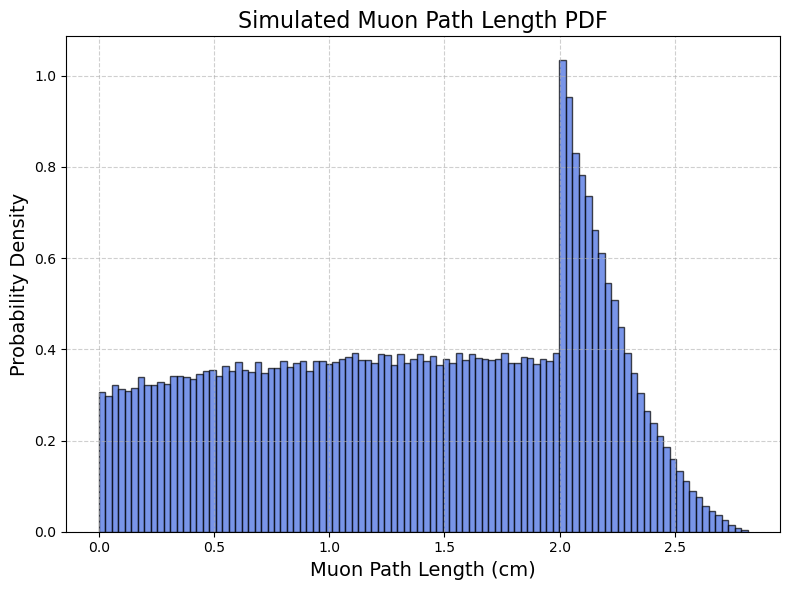

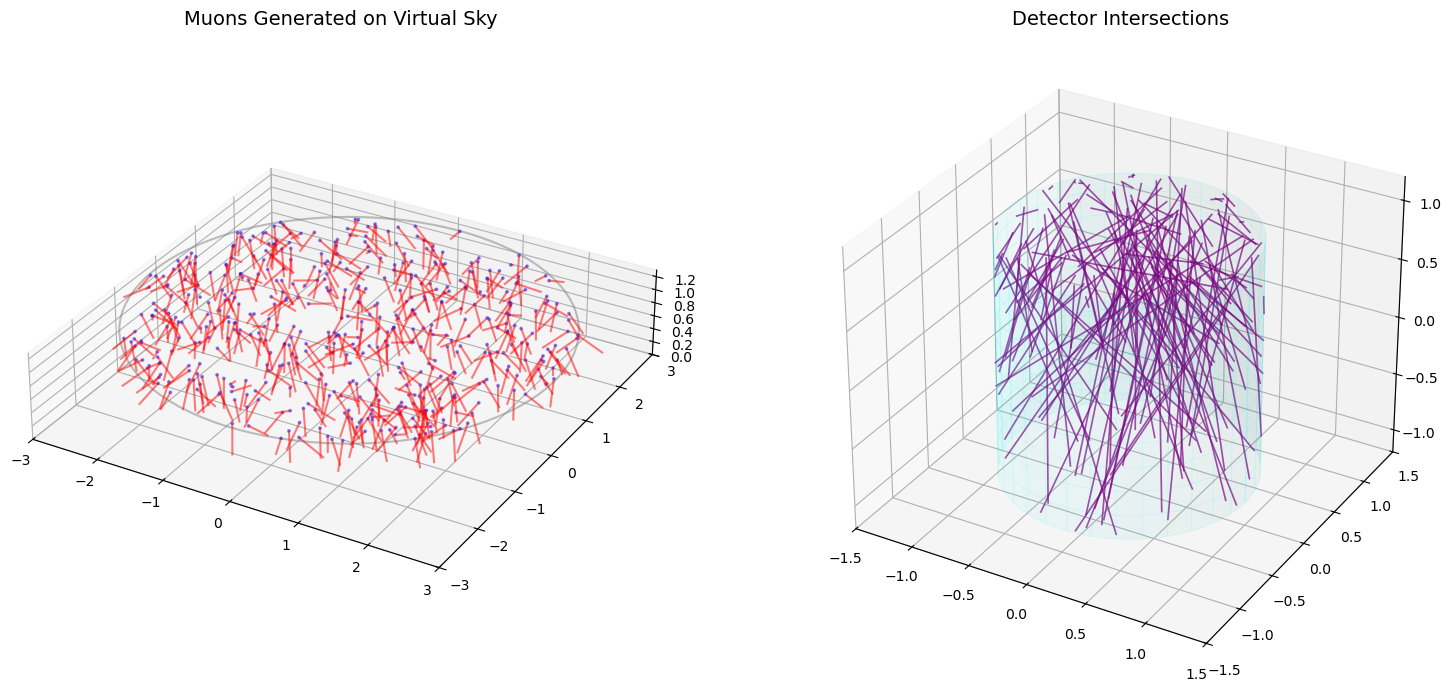

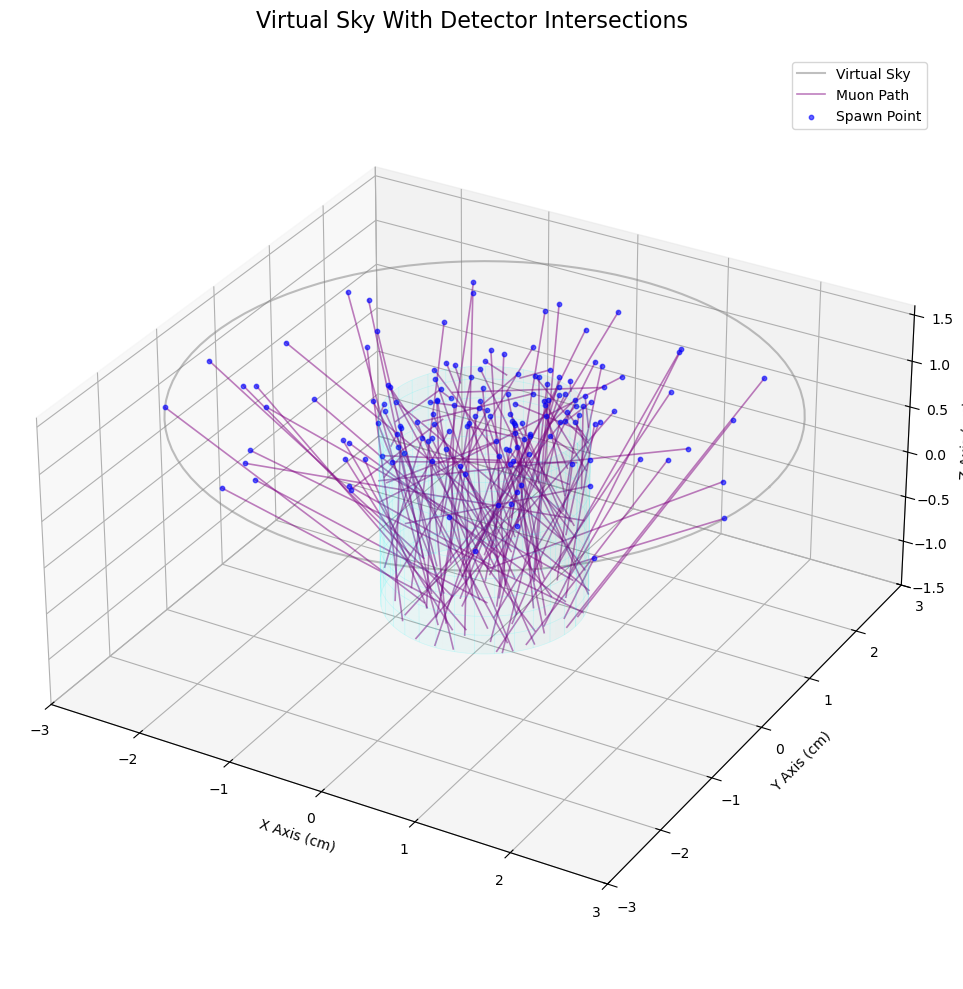

Calibration Factor: 0.0137 MeV/Channel


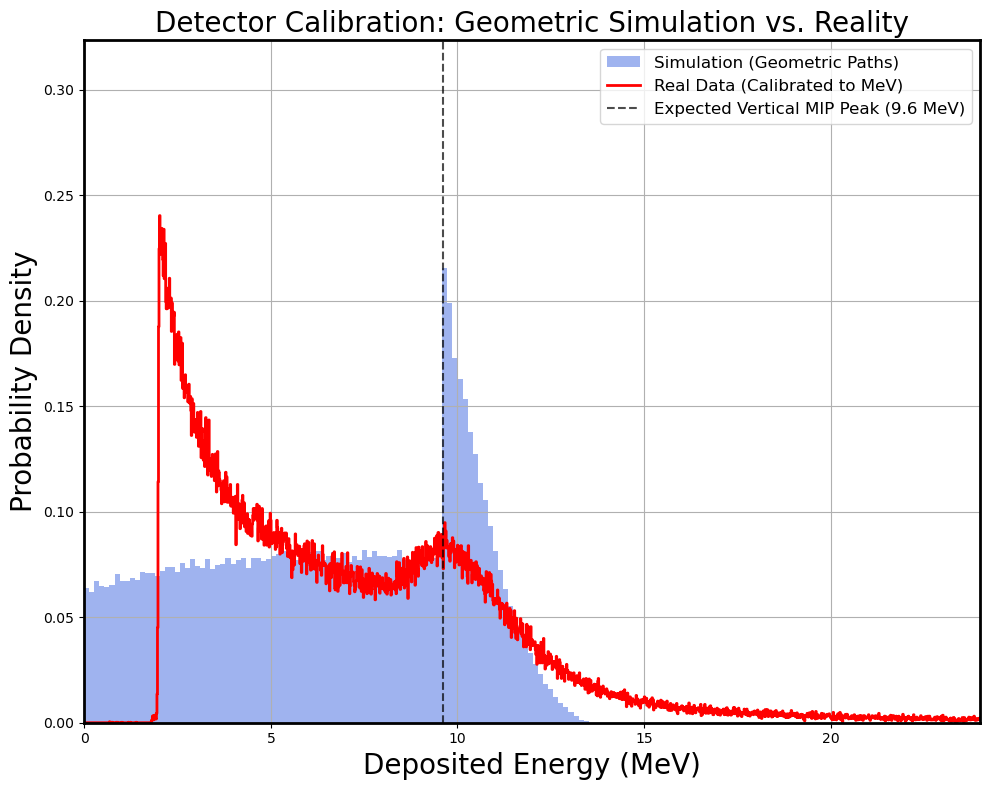

In [15]:
#Virtual sky method (geometry does the work, but less efficient)

import numpy as np

#Cylinder setup
r = 1
h = 2 #cm (Started with h=2, For 2x2cm detector h=5.08
z_sky = 1.1 #sky height
r_sky = 3 #sky radius
n = 1_000_000

#Generate muons on sky
phi_sky = np.random.uniform(0, 2 * np.pi, n)
R_sky = r_sky * np.sqrt(np.random.rand(n))

#Translate to cartesian
x0 = R_sky * np.cos(phi_sky)
y0 = R_sky * np.sin(phi_sky)
z0 = np.full(n, z_sky) #gives the value 1.1 to each generated x0 and y0 point

#Angle generation that follows cos^a without needing to filter
a = 2 #cos^a variable
phi = np.random.uniform(0, 2*np.pi, n) #Compass direction range
theta = np.arccos(np.random.rand(n) ** (1 / (a + 1)))


#Calculus to make theta generate according to the cos^a function instead of making it random and then filtering
import sympy as sp #Allows symbolic math
theta_sym, a_sym, u  = sp.symbols('theta_sym a_sym u', positive=True) #Ties written variables for python to algebraic symbols in sympy
pdf = (a_sym + 1) * (sp.cos(theta_sym)**a_sym) * (sp.sin(theta_sym)) #Gives our pdf of muon angle with normalization constant * desired distribution * geometric area equation factor
cdf = sp.integrate(pdf, theta_sym) #Integrates our pdf to find probability of being within any 0 to theta range
cdf_normalized = 1 - sp.cos(theta_sym)**(a_sym + 1) #Makes cdf spit out 0 at 0, and 1 as angle increases to pi/2
equation = sp.Eq(cdf_normalized, u) #Sets cdf equal to a random number variable so that we can solve for an output theta with an input of random cdf percentage

print("The Equation to solve is:")
sp.pprint(equation) #Shows equation to solve

solutions = sp.solve(equation, theta_sym) #Solvesequation for theta

print("\nSolving for theta gives:")
sp.pprint(solutions[0]) #Shows solved equation


          




#Build direction vectors by turning muon positions and angles into a continuous line
vx = np.sin(theta) * np.cos(phi) #distance from vertical axis * distance in x direction to give cartesian
vy = np.sin(theta) * np.sin(phi) #d from z-axis * distance in y to give cartesian coordinates
vz = -np.cos(theta) #distance along z axis (negative because downward)












#BELOW IS AI WORK TO COMPLETE CONCEPTS FOR POSTER PRESENTATION. DELETE AND RECREATE LATER.


# --- BLOCK 1: DETECTOR INTERSECTION & PATH LENGTHS ---
# Using the "Slab Method" for ray-cylinder intersection

# 1. Define Z-planes (Top and Bottom of the cylinder centered at z=0)
z_top = h / 2.0
z_bottom = -h / 2.0

# Calculate time (t) to hit the infinite horizontal planes
# Note: vz is negative, so t_top will be smaller (hit first) than t_bottom
t_top = (z_top - z0) / vz
t_bottom = (z_bottom - z0) / vz

# 2. Define Infinite Cylinder Walls (Quadratic equation)
a_quad = vx**2 + vy**2
b_quad = 2 * (x0*vx + y0*vy)
c_quad = x0**2 + y0**2 - r**2

disc = b_quad**2 - 4*a_quad*c_quad

# Safely calculate wall intersections (ignore negative discriminants to avoid math errors)
t_wall_in = np.where(disc >= 0, (-b_quad - np.sqrt(np.maximum(0, disc))) / (2*a_quad), -1)
t_wall_out = np.where(disc >= 0, (-b_quad + np.sqrt(np.maximum(0, disc))) / (2*a_quad), -1)

# 3. Find the true entry and exit times into the physical cylinder bounds
t_in = np.maximum(t_top, t_wall_in)
t_out = np.minimum(t_bottom, t_wall_out)

# 4. Filter for actual hits (Entry must happen before Exit, and discriminant must be >= 0)
valid_hits = (t_in < t_out) & (disc >= 0)

# Calculate final path lengths
path_lengths = t_out[valid_hits] - t_in[valid_hits]

print(f"Generated {n} muons.")
print(f"Total muons that intersected the detector: {np.sum(valid_hits)}")





# --- BLOCK 2: ENERGY CALIBRATION & HISTOGRAM (PDF) ---
import matplotlib.pyplot as plt

# NaI(Tl) Energy Conversion (approx 4.8 MeV per cm for minimum ionizing muons)
# (Assuming your 'r' and 'h' are in cm for this calculation)
energy_deposited_MeV = path_lengths * 4.8

# Plotting the Probability Density Function (PDF) of Path Lengths
fig, ax1 = plt.subplots(figsize=(8, 6))

# density=True normalizes it so the area under the curve is 1 (creates the PDF)
ax1.hist(path_lengths, bins=100, density=True, alpha=0.7, color='royalblue', edgecolor='black')

ax1.set_xlabel("Muon Path Length (cm)", fontsize=14)
ax1.set_ylabel("Probability Density", fontsize=14)
ax1.set_title("Simulated Muon Path Length PDF", fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
# SAVES HIGH-RES IMAGE TO YOUR FOLDER
plt.savefig("Simulated_Muon_Path_Length_PDF.png", dpi=300, bbox_inches='tight') 
plt.show()




# --- BLOCK 3: RESEARCH POSTER VISUALIZATIONS (ALL 3 PLOTS) ---
import matplotlib.pyplot as plt

hit_indices = np.where(valid_hits)[0]
hits_to_plot = min(150, len(hit_indices)) 

# VISUAL FIX: To show realistic vertical dominance, we prioritize hits that 
# spawned directly above the detector footprint (r < 1.2) for the isolated view.
core_hits = np.where(valid_hits & (np.sqrt(x0**2 + y0**2) < r * 1.2))[0]
if len(core_hits) < hits_to_plot: core_hits = hit_indices # Safety fallback

# Generate two different samples
np.random.seed(42) 
plot_sample_det = np.random.choice(core_hits, size=hits_to_plot, replace=False) # Mostly vertical
plot_sample_uni = np.random.choice(hit_indices, size=hits_to_plot, replace=False) # True random

# =====================================================================
# FIGURE 1: SIDE-BY-SIDE (SKY VS DETECTOR)
# =====================================================================
fig1 = plt.figure(figsize=(16, 7))

# --- Subplot 1: The Sky and Muon Vectors ---
ax_sky = fig1.add_subplot(121, projection='3d')
ax_sky.set_title("Muons Generated on Virtual Sky", fontsize=14, pad=15)

theta_circle = np.linspace(0, 2*np.pi, 100)
ax_sky.plot(r_sky * np.cos(theta_circle), r_sky * np.sin(theta_circle), z_sky, color='gray', alpha=0.5)

vis_n = min(500, n) 
ax_sky.scatter(x0[:vis_n], y0[:vis_n], z0[:vis_n], color='blue', s=3, alpha=0.4)

# arrow_length_ratio=0.0 removes the cluttering arrowheads!
ax_sky.quiver(x0[:vis_n], y0[:vis_n], z0[:vis_n], vx[:vis_n], vy[:vis_n], vz[:vis_n], 
              length=0.4, color='red', alpha=0.5, arrow_length_ratio=0.0)

ax_sky.set_xlim([-r_sky, r_sky])
ax_sky.set_ylim([-r_sky, r_sky])
ax_sky.set_zlim([0, z_sky + 0.2])
ax_sky.set_box_aspect((2*r_sky, 2*r_sky, z_sky + 0.2))

# --- Subplot 2: Detector Intersections ---
ax_det = fig1.add_subplot(122, projection='3d')
ax_det.set_title("Detector Intersections", fontsize=14, pad=15)

z_cyl = np.linspace(-h/2, h/2, 30)
theta_cyl_grid, z_cyl_grid = np.meshgrid(theta_circle, z_cyl)
x_cyl = r * np.cos(theta_cyl_grid)
y_cyl = r * np.sin(theta_cyl_grid)

ax_det.plot_surface(x_cyl, y_cyl, z_cyl_grid, color='cyan', alpha=0.05, edgecolor='none')
ax_det.plot_wireframe(x_cyl, y_cyl, z_cyl_grid, color='cyan', alpha=0.15, linewidth=0.5, rstride=3, cstride=3)
ax_det.plot_surface(r * np.cos(theta_cyl_grid), r * np.sin(theta_cyl_grid), np.full_like(z_cyl_grid, h/2), color='cyan', alpha=0.2)
ax_det.plot_surface(r * np.cos(theta_cyl_grid), r * np.sin(theta_cyl_grid), np.full_like(z_cyl_grid, -h/2), color='cyan', alpha=0.2)

# Plot the filtered vertical hits
for i in plot_sample_det:
    p_in = [x0[i] + vx[i]*t_in[i], y0[i] + vy[i]*t_in[i], z0[i] + vz[i]*t_in[i]]
    p_out = [x0[i] + vx[i]*t_out[i], y0[i] + vy[i]*t_out[i], z0[i] + vz[i]*t_out[i]]
    ax_det.plot([p_in[0], p_out[0]], [p_in[1], p_out[1]], [p_in[2], p_out[2]], color='purple', alpha=0.7, linewidth=1.2)

ax_det.set_xlim([-r*1.5, r*1.5])
ax_det.set_ylim([-r*1.5, r*1.5])
ax_det.set_zlim([-h/2 - 0.2, h/2 + 0.2])
ax_det.set_box_aspect((3*r, 3*r, h + 0.4)) 

plt.tight_layout()
# SAVES HIGH-RES IMAGE TO YOUR FOLDER
plt.savefig("Virtual_Sky_and_Detector.png", dpi=300, bbox_inches='tight')
plt.show()

# =====================================================================
# FIGURE 2: UNIFIED VIEW (SKY TO DETECTOR)
# =====================================================================
fig2 = plt.figure(figsize=(10, 10))
ax_uni = fig2.add_subplot(111, projection='3d')
ax_uni.set_title("Virtual Sky With Detector Intersections", fontsize=16, pad=20)

# Draw Virtual Sky at r=3
ax_uni.plot(r_sky * np.cos(theta_circle), r_sky * np.sin(theta_circle), z_sky, color='gray', alpha=0.5, label='Virtual Sky')

# Draw Detector Cylinder
ax_uni.plot_surface(x_cyl, y_cyl, z_cyl_grid, color='cyan', alpha=0.05, edgecolor='none')
ax_uni.plot_wireframe(x_cyl, y_cyl, z_cyl_grid, color='cyan', alpha=0.15, linewidth=0.5, rstride=3, cstride=3)
ax_uni.plot_surface(r * np.cos(theta_cyl_grid), r * np.sin(theta_cyl_grid), np.full_like(z_cyl_grid, h/2), color='cyan', alpha=0.2)
ax_uni.plot_surface(r * np.cos(theta_cyl_grid), r * np.sin(theta_cyl_grid), np.full_like(z_cyl_grid, -h/2), color='cyan', alpha=0.2)

# Plot the TRUE random hits (includes the diagonals)
for idx, i in enumerate(plot_sample_uni):
    p_out_x = x0[i] + vx[i]*t_out[i]
    p_out_y = y0[i] + vy[i]*t_out[i]
    p_out_z = z0[i] + vz[i]*t_out[i]
    
    label_path = 'Muon Path' if idx == 0 else "" 
    ax_uni.plot([x0[i], p_out_x], [y0[i], p_out_y], [z0[i], p_out_z], color='purple', alpha=0.5, linewidth=1.2, label=label_path)
    
    label_spawn = 'Spawn Point' if idx == 0 else ""
    ax_uni.scatter(x0[i], y0[i], z0[i], color='blue', s=10, alpha=0.6, label=label_spawn)

# Set visual bounds to fit the wide r=3 sky
ax_uni.set_xlim([-r_sky, r_sky])
ax_uni.set_ylim([-r_sky, r_sky])
ax_uni.set_zlim([-h/2 - 0.5, z_sky + 0.5])

z_range = (z_sky + 0.5) - (-h/2 - 0.5)
ax_uni.set_box_aspect((2*r_sky, 2*r_sky, z_range)) 

ax_uni.set_xlabel('X Axis (cm)')
ax_uni.set_ylabel('Y Axis (cm)')
ax_uni.set_zlabel('Z Axis (cm)')
ax_uni.legend(loc='upper right', prop={'size': 10})

plt.tight_layout()
# SAVES HIGH-RES IMAGE TO YOUR FOLDER
plt.savefig("Virtual_Sky_With Detector_Intersections.png", dpi=300, bbox_inches='tight')
plt.show()




# --- BLOCK 4: ENERGY CALIBRATION & DATA OVERLAY ---
import pandas as pds
import matplotlib.pyplot as plt

# 1. Physical Calibration Math
# 4.8 MeV deposited per cm in NaI. Peak energy = height * 4.8
energy_per_cm = 4.8 
theoretical_peak_MeV = h * energy_per_cm
experimental_peak_channel = 700.0

# Calculate conversion factor (MeV per Channel)
cal_factor = theoretical_peak_MeV / experimental_peak_channel
print(f"Calibration Factor: {cal_factor:.4f} MeV/Channel")

# Convert Simulated Path Lengths to Energy
simulated_energy_MeV = path_lengths * energy_per_cm

# 2. Import Real Experimental Data
# Using your exact pandas code
cosmics = pds.read_csv("../../cosmics_data/cosmics_NaI_Det2_260302_700V_3day.txt", 
                       skiprows=1, 
                       names=['Label','junk', 'BinHigh','BinLow','Counts'], 
                       sep='\s+', 
                       encoding='utf_16')

# Convert channels to real Energy (MeV)
x_channels = np.asarray(cosmics["BinLow"])
x_MeV = x_channels * cal_factor
y_counts = np.asarray(cosmics["Counts"])

# 3. Normalizing the Y-Axis (Counts to Density)
# Because the simulation is a Probability Density (area = 1), we must convert 
# your raw counts into a density so they fit on the same Y-axis scale.
dx = x_MeV[1] - x_MeV[0] if len(x_MeV) > 1 else 1.0
y_density = y_counts / (np.sum(y_counts) * dx)

# 4. Plotting the Overlay
fig_cal, ax_cal = plt.subplots(figsize=(10, 8))

# Plot Simulated Data
ax_cal.hist(simulated_energy_MeV, bins=100, density=True, alpha=0.5, 
            color='royalblue', label='Simulation (Geometric Paths)')

# Plot Real Data
ax_cal.step(x_MeV, y_density, where='post', color='red', linewidth=2, 
            label='Real Data (Calibrated to MeV)')

# Formatting
ax_cal.set_xlim(0, theoretical_peak_MeV * 2.5) # Zooms in to show the relevant muon peak

# We set the Y-limit to chop off the top of the massive environmental gamma spike 
# on the far left, so we can clearly see the muon hump.
# We auto-scale the Y-limit based on the height of the simulation peak.
sim_counts, _ = np.histogram(simulated_energy_MeV, bins=100, density=True)
ax_cal.set_ylim(0, np.max(sim_counts) * 1.5)

ax_cal.set_xlabel("Deposited Energy (MeV)", fontsize=20)
ax_cal.set_ylabel("Probability Density", fontsize=20)
ax_cal.set_title("Detector Calibration: Geometric Simulation vs. Reality", fontsize=20)

# Add a dashed line showing where the peaks are theoretically aligned
ax_cal.axvline(theoretical_peak_MeV, color='black', linestyle='--', alpha=0.7, 
               label=f'Expected Vertical MIP Peak ({theoretical_peak_MeV:.1f} MeV)')

ax_cal.legend(loc='upper right', fontsize=12)
ax_cal.grid(True)
ax_cal.yaxis.grid(True, which='minor', linestyle='--')

for axis in ['top','bottom','left','right']:
    ax_cal.spines[axis].set_linewidth(2)

plt.tight_layout()
# SAVES HIGH-RES OVERLAY IMAGE TO YOUR FOLDER
plt.savefig("Calibration_Data_Overlay.png", dpi=300, bbox_inches='tight')
plt.show()